In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Week-2

**Note to Learners**:

- For questions that involve plotting, just enter $0$ as the answer in the portal.
- For numerical questions, there are two parts. The first part expects you to compute some quantity, say a parameter of a machine learning model. The second part will require you to convert this quantity (if it is not a scalar) into a scalar so that it can be entered as the answer on the portal to the corresponding NAT question.



## Dataset

Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features. Ignore the vector $y$. You will be using this dataset for the rest of the assignment. Do not edit this cell.

In [15]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, factor=0.9, noise=0.2, random_state=0)

## Problem 1
Plot the dataset using matplotlib.

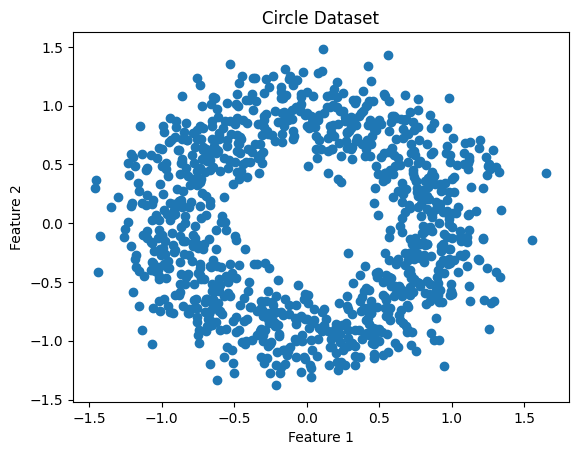

In [16]:
# Enter your solution here
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.title("Circle Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Problem 2
How many samples are there in the dataset?


In [17]:
# Enter your solution here
n_samples = X.shape[0]
print(n_samples)

1000


## Problem 3
How many features are there in the dataset?

In [18]:
# Enter your solution here
n_features = X.shape[1]
print(n_features)

2


## Problem 4
Find the kernel matrix $K$ using the polynomial kernel with degree $2$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} (K_{ij})^2}
$$

In [19]:
# Enter your solution here
import numpy as np

n = X.shape[0]

K_poly = (X @ X.T + 1) ** 2

value_poly = np.sqrt(np.sum(K_poly**2) / n)
print(round(value_poly, 2))

66.29


## Problem 5
Find the kernel matrix $K$ using the Gaussian kernel with parameter $\sigma = 2$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} (K_{ij})^2}
$$

In [20]:
# Enter your solution here
from sklearn.metrics.pairwise import rbf_kernel

n = X.shape[0]

sigma = 2
gamma = 1 / (2 * sigma**2)
K_rbf = rbf_kernel(X, gamma=gamma)

value_rbf = np.sqrt(np.sum(K_rbf**2) / n)
print(round(value_rbf, 2))

25.55


## Problem 6
Find the center of the kernel matrix $K$ obtained in problem 2. Call this centered matrix $KC$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} KC_{ij}^2}
$$

In [21]:
# Enter your solution here
import numpy as np

n = X.shape[0]
one_n = np.ones((n, n)) / n
Kc = K_poly - one_n @ K_poly - K_poly @ one_n + one_n @ K_poly @ one_n

value_centered = np.sqrt(np.sum(Kc**2) / n)
print(round(value_centered, 2))

45.91


## Problem 7
Find the projections (scalar) of all the data points on to the first two principal components obtained using polynomial kernel of degree 2.

<u>Conversion</u>

if $\alpha_1, \alpha_2, ..., \alpha_n$ are the prjections on the first PC and $\beta_1, \beta_2, ..., \beta_n$ are the projections on the second PC, enter the following quantity as your answer correct to two decimal places:

$$\sum_{i = 1}^{n} \alpha_i + \sum_{i = 1}^{n} \beta_i$$

In [22]:
# Enter your solution here
import numpy as np

n = X.shape[0]
eigvals, eigvecs = np.linalg.eigh(Kc)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

alpha = eigvecs[:, 0] * np.sqrt(eigvals[0])
beta = eigvecs[:, 1] * np.sqrt(eigvals[1])

result = np.sum(alpha) + np.sum(beta)
print(round(result, 2))

-0.0
